# Exploratory Data Analysis

This notebook explores the initial public market dataset before feature engineering or modeling. The first section independently loads the saved Parquet file and checks its dimensions, coverage, missing values, and duplicate observations.

> Note: This notebook records early exploratory analysis before the final modeling framework was completed. Some response and weighting questions are discussed here as open design questions; the finalized definitions are documented in `docs/modeling_problem.md`, `docs/data_dictionary.md`, and `docs/utility_score.md`.

In [20]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

current_directory = Path.cwd()

if current_directory.name == "notebooks":
    project_root = current_directory.parent
else:
    project_root = current_directory

data_path = (
    project_root
    / "data"
    / "raw"
    / "daily_prices_2016_2025.parquet"
)

data_path

WindowsPath('c:/Users/Sam/OneDrive/Documents/Quant Projects/jane-street-inspired-market-prediction/data/raw/daily_prices_2016_2025.parquet')

In [21]:
prices = pd.read_parquet(data_path)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [22]:
row_count, column_count = prices.shape
unique_dates = prices["date"].nunique()
unique_symbols = prices["symbol"].nunique()

print(f"Rows: {row_count:,}")
print(f"Columns: {column_count}")
print(f"First date: {prices['date'].min().date()}")
print(f"Last date: {prices['date'].max().date()}")
print(f"Unique trading dates: {unique_dates:,}")
print(f"Unique symbols: {unique_symbols}")

Rows: 77,934
Columns: 7
First date: 2016-01-04
Last date: 2025-12-31
Unique trading dates: 2,514
Unique symbols: 31


In [23]:
missing_summary = pd.DataFrame(
    {
        "missing_count": prices.isna().sum(),
        "missing_percent": prices.isna().mean() * 100,
    }
)

missing_summary

,missing_count,missing_percent
date,0,0.0
symbol,0,0.0
open,0,0.0
high,0,0.0
low,0,0.0
close,0,0.0
volume,0,0.0


In [24]:
duplicate_count = prices.duplicated(
    subset=["date", "symbol"]
).sum()

print(f"Duplicate date-symbol rows: {duplicate_count:,}")

Duplicate date-symbol rows: 0


In [25]:
expected_row_count = unique_dates * unique_symbols
panel_is_complete = row_count == expected_row_count

print(f"Expected rows in a complete panel: {expected_row_count:,}")
print(f"Actual rows: {row_count:,}")
print(f"Complete date-symbol panel: {panel_is_complete}")

Expected rows in a complete panel: 77,934
Actual rows: 77,934
Complete date-symbol panel: True


## Initial Quality Audit

The dataset loaded successfully and contains 77,934 observations covering 2,514 trading dates and 31 symbols. No columns contain missing values, no duplicate date-symbol keys were found, and the row count matches a complete panel containing one observation for every symbol on every trading date.

## Distributions and Observation Coverage

This section constructs several temporary variables that make the raw market data easier to compare across securities. It then examines their distributions and verifies that every trading date contains the expected number of symbol observations.

These variables are exploratory and are not yet part of the finalized modeling feature set.

In [26]:
eda = prices.sort_values(
    ["symbol", "date"]
).copy()

eda["previous_close"] = (
    eda.groupby("symbol")["close"]
    .shift(1)
)

eda["daily_return"] = (
    eda.groupby("symbol")["close"]
    .pct_change(fill_method=None)
)

eda["intraday_range"] = (
    (eda["high"] - eda["low"])
    / eda["close"]
)

eda["overnight_gap"] = (
    eda["open"]
    / eda["previous_close"]
    - 1
)

eda["dollar_volume"] = (
    eda["close"]
    * eda["volume"]
)

eda["log_volume"] = np.log1p(
    eda["volume"]
)

eda["log_dollar_volume"] = np.log1p(
    eda["dollar_volume"]
)

In [27]:
exploratory_columns = [
    "daily_return",
    "intraday_range",
    "overnight_gap",
    "log_volume",
    "log_dollar_volume",
]

eda[exploratory_columns].describe(
    percentiles=[
        0.01,
        0.05,
        0.50,
        0.95,
        0.99,
    ]
).T

,count,mean,std,min,1%,5%,50%,95%,99%,max
daily_return,77903.0,0.000753,0.017550,-0.263901,-0.048249,-0.024999,0.000757,0.025430,0.049816,0.359488
intraday_range,77934.0,0.019586,0.012661,0.001229,0.005119,0.007340,0.016381,0.042019,0.067659,0.250184
overnight_gap,77903.0,0.000445,0.010943,-0.245263,-0.030351,-0.013175,0.000515,0.013384,0.029910,0.321643
log_volume,77934.0,16.291961,1.294757,13.039201,14.107284,14.478645,16.138083,18.613074,20.055886,22.029685
log_dollar_volume,77934.0,20.855677,1.194668,17.713594,18.769339,19.347771,20.595365,23.317464,24.312354,25.597335


Plotting our five exploratory variables:

In [28]:
def plot_trimmed_histogram(
    series: pd.Series,
    title: str,
    x_label: str,
    bins: int = 75,
    lower_quantile: float = 0.005,
    upper_quantile: float = 0.995,
) -> None:
    """Plot the central portion of a variable's distribution."""
    clean_series = series.dropna()

    lower_bound = clean_series.quantile(
        lower_quantile
    )
    upper_bound = clean_series.quantile(
        upper_quantile
    )

    displayed_values = clean_series[
        clean_series.between(
            lower_bound,
            upper_bound,
        )
    ]

    fig, ax = plt.subplots(
        figsize=(8, 4.5)
    )

    ax.hist(
        displayed_values,
        bins=bins,
    )

    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel("Observations")

    plt.show()

    print(
        f"Displayed {len(displayed_values):,} of "
        f"{len(clean_series):,} nonmissing observations."
    )
    print(
        f"Displayed range: "
        f"{lower_bound:.4f} to {upper_bound:.4f}"
    )

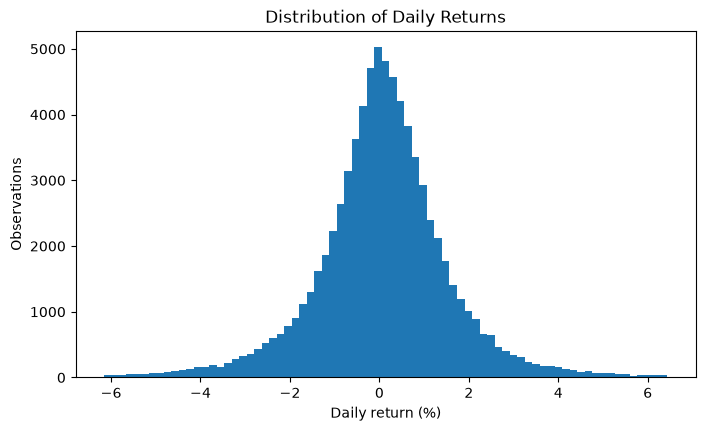

Displayed 77,123 of 77,903 nonmissing observations.
Displayed range: -6.1661 to 6.4430


In [29]:
plot_trimmed_histogram(
    eda["daily_return"] * 100,
    title="Distribution of Daily Returns",
    x_label="Daily return (%)",
)

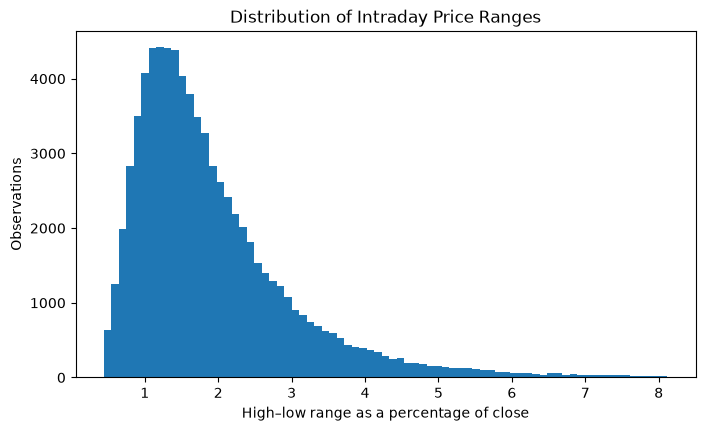

Displayed 77,154 of 77,934 nonmissing observations.
Displayed range: 0.4415 to 8.1231


In [30]:
plot_trimmed_histogram(
    eda["intraday_range"] * 100,
    title="Distribution of Intraday Price Ranges",
    x_label="High–low range as a percentage of close",
)

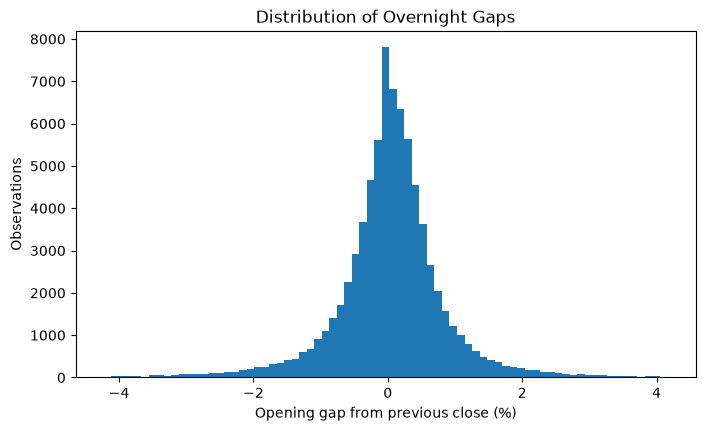

Displayed 77,123 of 77,903 nonmissing observations.
Displayed range: -4.2279 to 4.1626


In [31]:
plot_trimmed_histogram(
    eda["overnight_gap"] * 100,
    title="Distribution of Overnight Gaps",
    x_label="Opening gap from previous close (%)",
)

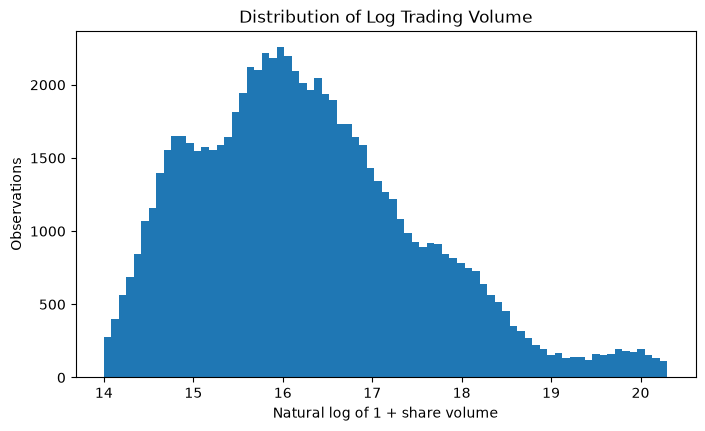

Displayed 77,154 of 77,934 nonmissing observations.
Displayed range: 13.9990 to 20.3010


In [32]:
plot_trimmed_histogram(
    eda["log_volume"],
    title="Distribution of Log Trading Volume",
    x_label="Natural log of 1 + share volume",
)

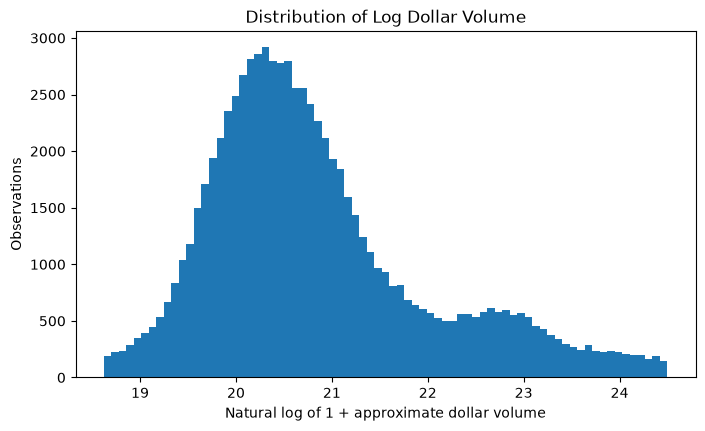

Displayed 77,154 of 77,934 nonmissing observations.
Displayed range: 18.6215 to 24.4993


In [33]:
plot_trimmed_histogram(
    eda["log_dollar_volume"],
    title="Distribution of Log Dollar Volume",
    x_label="Natural log of 1 + approximate dollar volume",
)

### Observation Coverage by Date

The intended panel contains one observation for each of the 31 symbols on every trading date. The following check counts rows on each date and identifies any dates with incomplete coverage.

In [34]:
rows_per_date = (
    prices.groupby("date")
    .size()
    .sort_index()
)

expected_symbols_per_date = (
    prices["symbol"].nunique()
)

incomplete_dates = rows_per_date[
    rows_per_date
    != expected_symbols_per_date
]

print(
    f"Unique trading dates: "
    f"{len(rows_per_date):,}"
)
print(
    f"Expected observations per date: "
    f"{expected_symbols_per_date}"
)
print(
    f"Minimum observations on one date: "
    f"{rows_per_date.min()}"
)
print(
    f"Maximum observations on one date: "
    f"{rows_per_date.max()}"
)
print(
    f"Incomplete dates: "
    f"{len(incomplete_dates):,}"
)

Unique trading dates: 2,514
Expected observations per date: 31
Minimum observations on one date: 31
Maximum observations on one date: 31
Incomplete dates: 0


Plotting coverage over time:

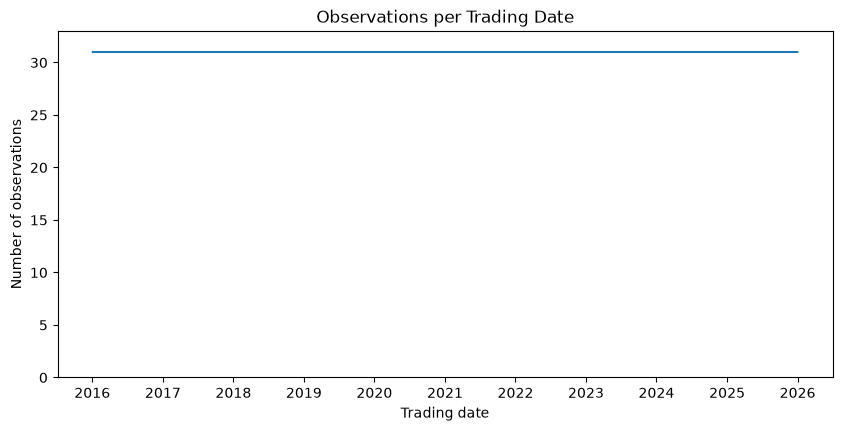

In [35]:
fig, ax = plt.subplots(
    figsize=(10, 4.5)
)

ax.plot(
    rows_per_date.index,
    rows_per_date.values,
)

ax.set_title(
    "Observations per Trading Date"
)
ax.set_xlabel("Trading date")
ax.set_ylabel("Number of observations")
ax.set_ylim(
    0,
    expected_symbols_per_date + 2,
)

plt.show()

In [36]:
if incomplete_dates.empty:
    print(
        "Every trading date contains all "
        f"{expected_symbols_per_date} symbols."
    )
else:
    incomplete_dates.to_frame(
        name="observation_count"
    )

Every trading date contains all 31 symbols.


## Interpretation and Initial Findings

This section explains how future response and weight variables will fit into the adapted prediction problem and records the first research observations raised by the exploratory analysis.

### Future Response and Weight Variables

The current raw dataset contains historical market observations but does not yet contain a prediction outcome or observation weight. A future `resp` variable will represent the return-related outcome that the model is trying to predict, calculated using market behavior after the assumed prediction time. The precise return horizon and whether the response will be an absolute or SPY-relative return remain open design decisions.

A future `weight` variable will determine how strongly each stock-date observation contributes to the project’s evaluation score. For example, weights might reflect liquidity or another measure of economic significance. An observation with a weight of zero would contribute nothing to the weighted utility calculation, regardless of its response value or the model’s decision. The weighting formula will be defined before the formal evaluation stage.


In [37]:
return_summary = eda["daily_return"].describe(
    percentiles=[0.01, 0.50, 0.99]
)

range_summary = eda["intraday_range"].describe(
    percentiles=[0.50, 0.95, 0.99]
)

gap_summary = eda["overnight_gap"].describe(
    percentiles=[0.01, 0.50, 0.99]
)

print("Daily return summary:")
print(return_summary)

print("\nIntraday range summary:")
print(range_summary)

print("\nOvernight gap summary:")
print(gap_summary)

Daily return summary:
count    77903.000000
mean         0.000753
std          0.017550
min         -0.263901
1%          -0.048249
50%          0.000757
99%          0.049816
max          0.359488
Name: daily_return, dtype: float64

Intraday range summary:
count    77934.000000
mean         0.019586
std          0.012661
min          0.001229
50%          0.016381
95%          0.042019
99%          0.067659
max          0.250184
Name: intraday_range, dtype: float64

Overnight gap summary:
count    77903.000000
mean         0.000445
std          0.010943
min         -0.245263
1%          -0.030351
50%          0.000515
99%          0.029910
max          0.321643
Name: overnight_gap, dtype: float64


The following code block provides some insight as to the sources of some of the unusual activity in the histogram tails:

In [38]:
extreme_return_rows = (
    eda.loc[
        eda["daily_return"].abs().nlargest(10).index,
        [
            "date",
            "symbol",
            "previous_close",
            "close",
            "daily_return",
        ],
    ]
    .sort_values(
        "daily_return",
        key=lambda values: values.abs(),
        ascending=False,
    )
)

extreme_return_rows.assign(
    daily_return_percent=(
        extreme_return_rows["daily_return"] * 100
    )
)

,date,symbol,previous_close,close,daily_return,daily_return_percent
75506,2025-09-10,ORCL,239.619110,325.759338,0.359488,35.948814
6778,2016-11-11,NVDA,1.664452,2.160569,0.298066,29.806632
47538,2022-02-03,META,320.188263,235.690262,-0.263901,-26.390099
53242,2022-10-27,META,128.689911,97.087418,-0.245571,-24.557087
57711,2023-05-25,NVDA,30.475470,37.902229,0.243696,24.369632
55288,2023-02-02,META,151.787064,187.126755,0.232824,23.282413
32928,2020-03-24,CVX,41.190014,50.556900,0.227407,22.740672
72441,2025-04-17,UNH,565.763977,439.147858,-0.223797,-22.379671
32804,2020-03-18,CVX,53.701988,41.820549,-0.221248,-22.124766
32726,2020-03-13,ORCL,36.420010,43.859585,0.204272,20.427164


### Initial Research Observations

**Surprising result:** The log-volume distributions contain a large central mode together with several smaller local peaks. Because the dataset pools multiple securities with different typical trading volumes, these smaller modes may reflect differences among individual stocks rather than a single common volume distribution.

**Expected result:** Daily returns and overnight gaps are concentrated near zero and appear approximately symmetric through the center of their distributions, although both retain substantial tails. This supports the expectation that most stock-date observations involve relatively modest price changes, while unusually large movements occur occasionally.

**Open question:** Which securities and market periods contribute most strongly to the extreme returns, gaps, and volume patterns, and can identifying those sources help us construct more informative features or predict market-relative outcomes?
